<a href="https://colab.research.google.com/github/marcushgrigsby39-web/Machine-Learning-with-python-Bootcamp./blob/main/EDA_%26_Data_Cleaning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading & Presevring

In [ ]:
import pandas as pd

# 1. The data Link
url = "https://raw.githubusercontent.com/marcushgrigsby39-web/Machine-Learning-with-python-Bootcamp./refs/heads/main/market_dirty.csv"

# 2. Read the data
df = pd.read_csv(url)

# 3. KEEP A RAW COPY for comparison
df_raw = df.copy()

# Look at the first few rows
print(df.head())


         date  rainfall_mm  transport_cost_lrd  supply_bags  price_lrd  \
0  2026-04-01         17.7              2935.0          158     3261.0   
1  2026-04-02         19.4              3843.0           45     4182.0   
2  2026-04-03         50.9              2655.0          218     2941.0   
3  2026-04-04          8.2              2268.0          221     4131.0   
4  2026-04-05         42.5              2369.0          220     3268.0   

   scarcity_alert  
0            True  
1            True  
2            True  
3           False  
4            True  


Asking the Data Qustions

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                40 non-null     object 
 1   rainfall_mm         40 non-null     float64
 2   transport_cost_lrd  40 non-null     float64
 3   supply_bags         40 non-null     int64  
 4   price_lrd           38 non-null     float64
 5   scarcity_alert      40 non-null     bool   
dtypes: bool(1), float64(3), int64(1), object(1)
memory usage: 1.7+ KB


In [ ]:
df.isna().sum()

,0
date,0
rainfall_mm,0
transport_cost_lrd,0
supply_bags,0
price_lrd,2
scarcity_alert,0


In [ ]:
# Drop rows where price is empty
df =df.dropna(subset=['price_lrd'])

# See how many records survived
print(f'original:{len(df_raw)}')
print(f'clean:{len(df)}')

original:40
clean:38


Filling in the Gaps

In [ ]:
# 1: Find the middle (median) transport cost
middle_cost = df['price_lrd'] .median()

# 2 : Fill the blank cells with this middle vaule
df['price_lrd'] = df['price_lrd'].fillna(middle_cost)

# verify: The blank should now be 0
print(df[f'price_lrd']. isna(). sum())

0


/tmp/ipykernel_4447/2409744057.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_lrd'] = df['price_lrd'].fillna(middle_cost)


The "Speed Limit"

In [ ]:
# Find the Speed Limit (Top 5% boundary)
Limit = df['price_lrd']. quantile(0.95)

# Bring the crazy spikes down to the limit
df['price_lrd']. clip(upper=Limit)

,price_lrd
0,3261.0
1,4182.0
2,2941.0
3,4131.0
4,3268.0
6,3848.0
7,3015.0
8,3539.0
9,3291.0
10,2835.0


Comparing Before & After

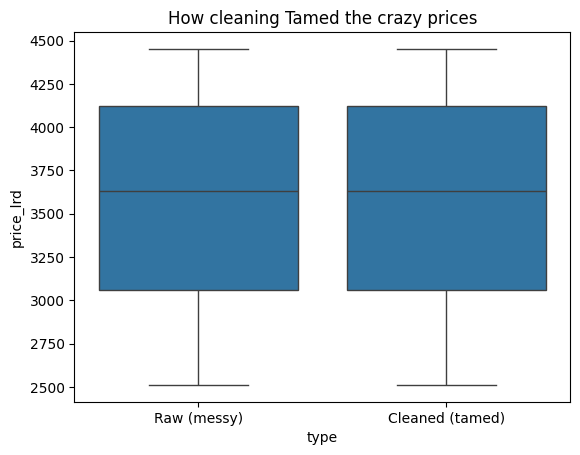

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a Dataframe for df_raw prices with a 'type' column
df_raw_prices = df_raw['price_lrd'].to_frame(name='price_lrd')
df_raw_prices['type'] = 'Raw (messy)'

# Create a DataFrame for cleaned prices with a 'type' column
df_clean_plot = df['price_lrd'].to_frame(name='price_lrd')
df_clean_plot['type'] = 'Cleaned (tamed)'

# concatenate these two Dataframes, ignoring their indices, to create long-form data
plot_data = pd.concat([df_raw_prices, df_clean_plot], ignore_index=True)

sns.boxplot(x='type', y='price_lrd', data=plot_data)
plt.title('How cleaning Tamed the crazy prices')
plt.show()

To ensure the `gari_price_data.csv` file is available for loading, I'll save the currently processed DataFrame `df` to this file name.

In [ ]:
# Save the processed DataFrame to 'gari_price_data.csv'
df.to_csv('gari_price_data.csv', index=False)
print('DataFrame saved to gari_price_data.csv')

DataFrame saved to gari_price_data.csv


Regerssion

In [ ]:
# Verbatin Step 1 Code BLOCK
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


# Load our model-ready dataset
df = pd.read_csv('https://raw.githubusercontent.com/marcushgrigsby39-web/Machine-Learning-with-python-Bootcamp./refs/heads/main/gari_price_data.csv')
print(df.head())
print(df.shape)


   rainfall_mm  transport_cost_lrd  supply_bags  price_next_day_lrd
0         18.7                2702          111              3179.0
1         47.5                2401           86              3178.0
2         36.6                2729          148              3060.0
3         29.9                2161          153              2851.0
4          7.8                2201           84              2907.0
(50, 4)


Features Selection

In [ ]:
X = df[['rainfall_mm','transport_cost_lrd', 'supply_bags']]
y = df['price_next_day_lrd']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Traning rows:',  x_train.shape[0])
print('Testing rows: ' , x_test.shape[0])

Traning rows: 40
Testing rows:  10


Training & Prediction

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('Intercept:', round(model.intercept_, 2))
print('coefficients:', dict(zip(X.columns, np.round(model.coef_, 2))))


Intercept: 2464.17
coefficients: {'rainfall_mm': np.float64(4.3), 'transport_cost_lrd': np.float64(0.3), 'supply_bags': np.float64(-2.35)}
